$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{February 13, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 3: Linear Regression}
\end{array}
$$

---

# Causal Regression & Introduction to Statistics — Recitation 3
---
We cover today's material in the following steps:
1. **Part 1**: From Prediction to Causation — A new interpretation of regression
2. **Part 2**: The Three Assumptions — Homogeneity, Linearity, Exogeneity
3. **Part 3**: Regression for Experiments — Potential Outcomes & the Average Treatment Effect (ATE)
4. **Part 4**: Simulating a Randomized Controlled Trial (RCT) vs. Observational Data in Python
5. **Part 5**: Statistics — Parameters vs. Estimators
6. **Part 6**: Consistency & the Weak Law of Large Numbers (WLLN) — Simulated
7. **Part 7**: The Continuous Mapping Theorem (CMT) & Sample Variance Convergence
- Let's code!!

---

## Part 1: From Prediction to Causation

- In the last two recitations, we defined the regression parameters $\beta_0, \beta_1$ two ways:
  - **Best Linear Predictor (BLP)** — minimizing $E[(Y - b_0 - b_1 X)^2]$
  - **Best linear approximation to $E[Y \mid X]$** — a descriptive view of how the average of $Y$ changes with $X$

- These definitions work for **any** random vector $(Y, X)$ — the relationship can be strong, weak, nonexistent, correlational, causal, whatever

- And under both definitions, the key properties $E[\varepsilon] = 0$ and $E[X\varepsilon] = 0$ hold **by definition** — meaning $\beta_0$ and $\beta_1$ can (basically) always be estimated

- But what if we don't just want to *predict* $Y$ or *describe* its relationship with $X$?

- What if we want to know: **does $X$ causally affect $Y$?** Can we change $X$ (via policy, intervention, etc.) and expect $Y$ to change as a result?

- This requires an entirely different framework — the **causal regression model**

---

## Part 2: The Three Assumptions — Homogeneity, Linearity, Exogeneity

- When we want a **causal** interpretation, we **assume** the causal relationship between $X$ and $Y$ takes a linear form:

$$Y = \alpha_0 + \alpha_1 X + U$$

- We use different notation ($\alpha$ instead of $\beta$) to distinguish the causal model from the descriptive/predictive one

- Here, $\alpha_1$ represents the **causal effect** on $Y$ of increasing $X$ by 1 unit

- $U$ is no longer just a prediction error — it represents **all other causal determinants of $Y$**

- For this model to be valid and estimable, we need three conditions:

  1. **Homogeneity**: The causal effect of $X$ on $Y$ is the same for everyone. Example: does height help you compete in the Olympics? For basketball, yes — but for gymnastics, height is a *disadvantage*. The effect varies across sports, so homogeneity fails!

  2. **Linearity**: The causal relationship is (at least approximately) linear. Example: the effect of age on 100m dash time is U-shaped — you get faster, then slower. A linear model might suggest *no effect* when there clearly is one. (Though we can sometimes fix this by regressing on a transformation, like $(age - 25)^2$)

  3. **Exogeneity**: $X$ is unrelated to other determinants of $Y$, i.e. $E[XU] = 0$. Since we can always normalize so that $E[U] = 0$, this is equivalent to $Cov(X, U) = 0$. Unlike the descriptive case, **this doesn't hold by definition** — it's a substantive assumption!

- **Why exogeneity can fail**: Suppose we want the causal effect of education debt ($X$) on lifetime wealth ($Y$). But debt is associated with how many degrees you have, and more degrees → more income → higher wealth. So $X$ is correlated with $U$ (other determinants of wealth), and a regression might show a *positive* relationship between debt and wealth — clearly not the causal effect!

- Generally, exogeneity will only hold if $X$ is **randomly generated** — either by an experiment or some natural random process

---

## Part 3: Regression for Experiments — Potential Outcomes & the Average Treatment Effect (ATE)

- So when *can* we estimate a causal regression model? One special case: **$X$ is experimentally assigned and binary**

- Example: we run an experiment to see how taking Ozempic affects weight:
  - $Y$ = weight 1 year later
  - $X = 1$ if given Ozempic, $X = 0$ if not

- In this setting, we can express causality flexibly using **potential outcomes**:
  - $Y^1$ = weight someone *would have* if given Ozempic
  - $Y^0$ = weight someone *would have* if not given Ozempic

- Because $X$ is **randomly assigned** in the experiment, who receives treatment doesn't depend on what their outcomes would be. Formally: $X \perp Y^1, Y^0$. This doesn't mean $X$ has no effect on $Y$ — it means the **assignment mechanism** is unrelated to the potential outcomes

- We can write: $Y = Y^0 + (Y^1 - Y^0)X$

- Taking conditional expectations and using independence:

$$E[Y \mid X] = E[Y^0] + X \cdot E[Y^1 - Y^0]$$

- This gives us a clean linear model $Y = \alpha_0 + \alpha_1 X + U$ where:
  - $\alpha_0 = E[Y^0]$ — the average outcome without treatment
  - $\alpha_1 = E[Y^1 - Y^0]$ — the **Average Treatment Effect (ATE)**

- And we can show that $E[XU] = 0$ holds automatically (by the properties of conditional expectations), so the model is estimable!

- **Key takeaway**: In the special case of a randomized experiment with binary $X$, all three assumptions (homogeneity, linearity, exogeneity) are satisfied **without any objectionable assumptions** — the potential outcomes framework does the heavy lifting for us

---

## Part 4: Simulating a Randomized Controlled Trial (RCT) vs. Observational Data

- Let's try and simulate the Ozempic-style experiment with a **known** true treatment effect
- First, we run a proper RCT (random assignment) and show OLS recovers the true ATE
- Then, we simulate **observational** (non-random) data where treatment is correlated with other determinants of $Y$ — and see how the estimate becomes biased

### Simulating a Randomized Controlled Trial (RCT)

- In our experiment, each person is either given Ozempic ($X = 1$) or not ($X = 0$) — so $X$ is binary
- Random assignment means each person has an equal probability of being treated — like flipping a fair coin
- A coin flip is a **Bernoulli trial** (success/failure with some probability $p$), and `np.random.binomial(1, 0.5)` is exactly that — it returns 1 with probability 0.5 and 0 with probability 0.5, independently for each person
- We set the true treatment effect to $\alpha_1 = -15$ (Ozempic reduces weight by 15 lbs on average) and see if OLS can recover it

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

In [2]:
# --- Simulating a Randomized Controlled Trial ---
n = 1000

# Random treatment assignment — fair coin flip for each person
X = np.random.binomial(1, 0.5, size=n)

# True parameters
alpha_0 = 200       # average weight without Ozempic (lbs)
alpha_1 = -15       # true ATE: Ozempic reduces weight by 15 lbs

# U = all other determinants of weight, independent of X by design
U = np.random.normal(0, 20, size=n)

# Observed outcome
Y = alpha_0 + alpha_1 * X + U

# Estimate via OLS
X_ols = sm.add_constant(X)
model_rct = sm.OLS(Y, X_ols).fit()
print("=== RCT: Random Assignment ===")
print(f"True α₀ = {alpha_0}, True α₁ = {alpha_1}")
print(f"Estimated α₀ = {model_rct.params[0]:.2f}, Estimated α₁ = {model_rct.params[1]:.2f}")

=== RCT: Random Assignment ===
True α₀ = 200, True α₁ = -15
Estimated α₀ = 202.32, Estimated α₁ = -15.70


### What happens without random assignment?

- Now suppose we don't run an experiment — instead, we just observe who takes Ozempic and who doesn't
- In the real world, people who take Ozempic might already be heavier, more health-conscious, have higher income (affording the drug), etc.
- This means $X$ (taking Ozempic) becomes **correlated with $U$** (other determinants of weight) — exogeneity fails!
- Let's simulate this: we'll make treatment more likely for people who are already heavier (i.e. who have higher $U$)

In [5]:
# --- Simulating Observational (Confounded) Data ---
n = 1000

# True parameters (same as before)
alpha_0 = 200
alpha_1 = -15

# U = other determinants of weight — generated first this time
U = np.random.normal(0, 20, size=n)

# Treatment is NOT random — people with higher U (heavier) are more likely to take Ozempic
prob_treatment = 1 / (1 + np.exp(-0.1 * U))   # higher U → higher probability of X=1
X = np.random.binomial(1, prob_treatment)

# Observed outcome
Y = alpha_0 + alpha_1 * X + U

# Estimate via OLS
X_ols = sm.add_constant(X)
model_obs = sm.OLS(Y, X_ols).fit()
print("=== Observational: Confounded Assignment ===")
print(f"True α₁ = {alpha_1}")
print(f"Estimated α₁ = {model_obs.params[1]:.2f} ")
print(f"\nFor comparison, RCT estimate was: {model_rct.params[1]:.2f}")

=== Observational: Confounded Assignment ===
True α₁ = -15
Estimated α₁ = 8.53 

For comparison, RCT estimate was: -15.70


### What just happened?

- In the RCT, OLS estimated $\alpha_1 \approx -15.70$ — right on target
- In the observational data, the estimate is **biased upward** because people who take Ozempic tend to be heavier to begin with
- The regression is picking up a mix of the true drug effect *and* the fact that heavier people selected into treatment
- This is exactly the debt → wealth example from lecture: correlation $\neq$ causation when $E[XU] \neq 0$
- **Takeaway**: without random assignment, a causal interpretation of regression can be seriously misleading

---

## Part 5: Statistics — Parameters vs. Estimators

- So far, we've been working with **parameters** — numbers like $\beta_0$, $\beta_1$, $\alpha_0$, $\alpha_1$, $E[X]$, $Var(X)$ that characterize the joint distribution of our random variables

- These are "real" numbers — but in practice, we don't know the full distribution, so we can't just compute them directly

- Instead, we **estimate** them using data. Estimation is the process of taking a sample, applying a function to it, and treating the result as our best guess of the parameter

- If $X_1, X_2, \ldots, X_n$ are **independent and identically distributed (i.i.d.)** draws from the distribution of $X$, we call this an i.i.d. sample

- An **estimator** is a function of the sample that gives us a guess of our parameter $\theta$:

$$\hat{\theta}_n = \hat{\theta}_n(X_1, X_2, \ldots, X_n)$$

- Key distinction: $\theta$ is a fixed number, but $\hat{\theta}_n$ is a **random variable** — because the sample is random, the estimate is random too

- The simplest example: to estimate $\theta = E[X]$, the natural estimator is the **sample mean**:

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$$

- But how do we know if an estimator is any good? We evaluate it by looking at properties of its **distribution**:

  - **Bias**: $\text{Bias}[\hat{\theta}_n] = E[\hat{\theta}_n] - \theta$. If bias is zero, the estimator is **unbiased** — correct on average. The sample mean is unbiased for $E[X]$ at *any* sample size

  - **Variance**: $Var(\hat{\theta}_n)$ tells us how spread out our estimates would be across different samples. For the sample mean: $Var(\bar{X}_n) = \frac{1}{n}Var(X)$ — variance shrinks with sample size. This is one reason we want large samples!

  - Being unbiased alone isn't enough — we also want low variance so our estimates are reliably close to the truth

---

## Part 6: Consistency & the Weak Law of Large Numbers (WLLN) — Simulated

- Unbiasedness is a **finite-sample** property — it holds at any $n$

- But we also care about what happens as we collect more and more data. This leads to a **large-sample** property: **consistency**

- An estimator $\hat{\theta}_n$ is **consistent** if it gets arbitrarily close to the true parameter as $n \to \infty$. Formally, for any $\varepsilon > 0$:

$$P(|\hat{\theta}_n - \theta| > \varepsilon) \to 0 \quad \text{as } n \to \infty$$

- This is called **convergence in probability**, written $\hat{\theta}_n \xrightarrow{p} \theta$

- The **Weak Law of Large Numbers (WLLN)** says: if $X_1, \ldots, X_n$ are i.i.d. with $E[X^2] < \infty$, then the sample mean is a consistent estimator for $E[X]$:

$$\bar{X}_n \xrightarrow{p} E[X]$$

- This is remarkable — it works for **any** distribution (as long as the variance exists)!

- Let's see it in action, just like in lecture — simulating die rolls at increasing sample sizes

### Die Roll Simulation
- A fair die takes values $\{1, 2, 3, 4, 5, 6\}$, each with probability $\frac{1}{6}$
- The true expectation is: $E[X] = \frac{1}{6}(1 + 2 + 3 + 4 + 5 + 6) = 3.5$
- As we roll the die more and more times, the sample mean should converge to 3.5

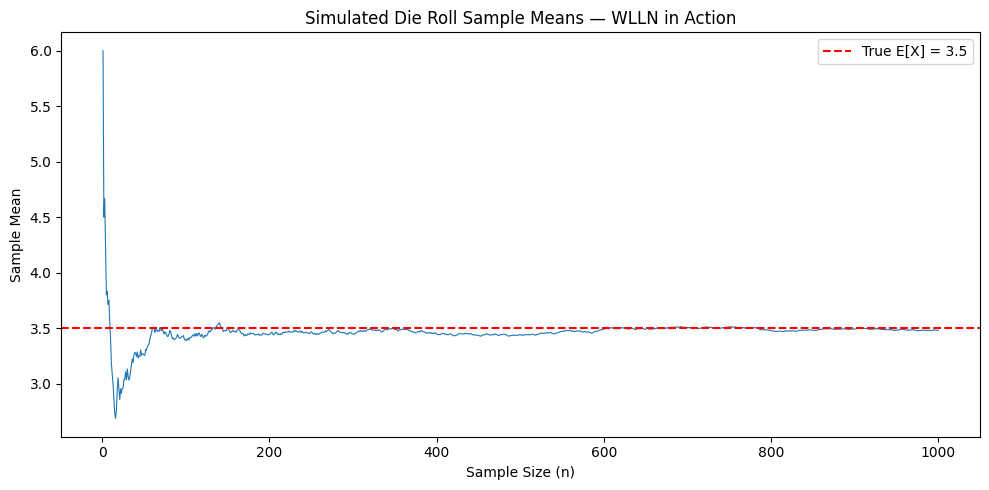

In [6]:
# --- WLLN: Die Roll Simulation ---
np.random.seed(123)

max_n = 1000
rolls = np.random.randint(1, 7, size=max_n)  # rolls of a fair die

# Compute running sample mean
sample_means = np.cumsum(rolls) / np.arange(1, max_n + 1)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_n + 1), sample_means, linewidth=0.8)
plt.axhline(y=3.5, color='red', linestyle='--', linewidth=1.5, label='True E[X] = 3.5')
plt.xlabel('Sample Size (n)')
plt.ylabel('Sample Mean')
plt.title('Simulated Die Roll Sample Means — WLLN in Action')
plt.legend()
plt.tight_layout()
plt.show()

### What are we seeing?

- With small samples, the sample mean jumps around wildly — could be far from 3.5
- As $n$ grows, it settles closer and closer to the true expectation
- This is the WLLN: the probability of being far from $E[X] = 3.5$ shrinks toward zero

---

## Part 7: The Continuous Mapping Theorem (CMT) & Sample Variance Convergence

- The WLLN is powerful — it tells us the sample mean converges to $E[X]$. But what if the parameter we care about isn't a simple mean?

- For example, the variance is $Var(X) = E[X^2] - E[X]^2$. This is a **function of two means** — $E[X^2]$ and $E[X]$. The WLLN tells us each of those sample means converges individually, but how do we know that plugging them into the formula $E[X^2] - E[X]^2$ also gives us something that converges?

- This is exactly what the **Continuous Mapping Theorem (CMT)** provides: if $X_n \xrightarrow{p} x$ and $Y_n \xrightarrow{p} y$, then for any function $g$ that is continuous at $(x, y)$:

$$g(X_n, Y_n) \xrightarrow{p} g(x, y)$$

- In other words, continuous functions preserve convergence in probability 

- **Application: Sample Variance.** Consider the estimator:

$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n} X_i^2 - (\bar{X}_n)^2$$

- This is a (slightly) biased estimator of the variance (why?) — but using WLLN + CMT, we can show it's **consistent**:

$$\frac{1}{n}\sum_{i=1}^{n} X_i^2 \xrightarrow{p} E[X^2] \quad \text{(WLLN)}$$

$$\bar{X}_n \xrightarrow{p} E[X] \quad \text{(WLLN)}$$

$$\frac{1}{n}\sum_{i=1}^{n} X_i^2 - (\bar{X}_n)^2 \xrightarrow{p} E[X^2] - E[X]^2 = Var(X) \quad \text{(CMT, using } g(a,b) = a - b^2\text{)}$$

- This WLLN + CMT strategy is used to prove consistency of many estimators — including the Ordinary Least Squares (OLS) estimator for regression parameters!

- Let's verify with our die roll example: $Var(X) = E[X^2] - E[X]^2 = \frac{1}{6}(1 + 4 + 9 + 16 + 25 + 36) - 3.5^2 = \frac{91}{6} - 12.25 \approx 2.917$

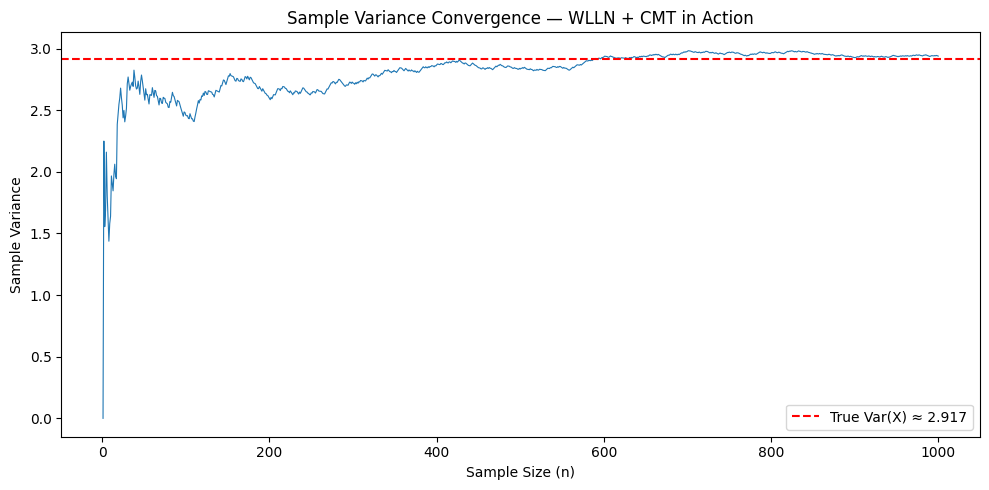

In [8]:
# --- Sample Variance Convergence (Die Rolls) ---
np.random.seed(123)

max_n = 1000
rolls = np.random.randint(1, 7, size=max_n)

true_variance = 91/6 - 3.5**2  # ≈ 2.917

# Compute running sample variance: (1/n)ΣXi² - (X̄n)²
cumulative_mean_sq = np.cumsum(rolls**2) / np.arange(1, max_n + 1)
cumulative_mean = np.cumsum(rolls) / np.arange(1, max_n + 1)
sample_variances = cumulative_mean_sq - cumulative_mean**2

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_n + 1), sample_variances, linewidth=0.8)
plt.axhline(y=true_variance, color='red', linestyle='--', linewidth=1.5, label=f'True Var(X) ≈ {true_variance:.3f}')
plt.xlabel('Sample Size (n)')
plt.ylabel('Sample Variance')
plt.title('Sample Variance Convergence — WLLN + CMT in Action')
plt.legend()
plt.tight_layout()
plt.show()

### Wrapping up

- Just like the sample mean converged to $E[X]$, the sample variance converges to $Var(X)$ — consistency via the WLLN + CMT

- These are the building blocks for showing that more complex estimators (like OLS) are also consistent 

## Summary

- **Causal Regression Model**: When we want a causal interpretation of regression, we write $Y = \alpha_0 + \alpha_1 X + U$ and need three assumptions to hold: homogeneity (same effect for everyone), linearity (relationship is approximately linear), and exogeneity ($E[XU] = 0$, i.e. $X$ is unrelated to other determinants of $Y$)

- **Why exogeneity matters**: Unlike the descriptive/predictive case, $E[XU] = 0$ doesn't hold by definition — if $X$ is correlated with $U$, our estimate will be biased and misleading (as we saw in the Ozempic simulation)

- **Experiments save the day**: When $X$ is randomly assigned and binary, the potential outcomes framework gives us a clean linear model where all three assumptions are satisfied automatically, and $\alpha_1 = E[Y^1 - Y^0]$ is the Average Treatment Effect (ATE)

- **Parameters vs. Estimators**: Parameters ($\theta$) are fixed numbers we want to know; estimators ($\hat{\theta}_n$) are random variables computed from data that serve as our best guess

- **Properties of estimators**: Bias tells us if we're correct on average (finite-sample); consistency tells us if we get closer to the truth as $n$ grows (large-sample)

- **Weak Law of Large Numbers (WLLN)**: The sample mean is a consistent estimator for $E[X]$ — we saw this with the die roll simulation converging to 3.5

- **Continuous Mapping Theorem (CMT)**: Continuous functions preserve convergence in probability — combined with the WLLN, this lets us prove consistency of more complex estimators like the sample variance and (eventually) Ordinary Least Squares (OLS)

---

## Office Hours Friday 11 AM - 1 PM  Room No - 244
or dropin your questions at vka244@nyu.edu

---

---